## CV plot 2D: LaDOTA

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import curve_fit
import os 
import glob
import re

In [ ]:
cwd = "./SAP-TSAP"

## 1. Plot COLVAR file

The COLVAR files contains most of the interesting output of the simulation. Let's have a look at the first few lines.

As the first line points out, the columns correspond to the time (in ps), the mean of the kernels, the number of kernels that are above the threshold ~0.5, the metadynamics bias, the bias for reweighting, and the c(t)

Let's plot some of this quantities.

In [2]:
def plot_column(data, headers):
    n_plots = len(headers) - 1  # Exclude time column
    fig, axes = plt.subplots(n_plots, 1, figsize=(10, 2 * n_plots), sharex=True)
    if n_plots == 1:
        axes = [axes]  # Ensure iterable

    # Plot each column
    for i, ax in enumerate(axes, start=1):  # start=1 to skip time
        ax.scatter(data[:, 0], data[:, i]+1E-10)
        ax.set_ylabel(headers[i])
        ax.grid(True)
        #ax.set_yscale('log')
    axes[-1].set_xlabel("time")
    plt.tight_layout()
    #plt.savefig("all_columns_vs_time.png")
    plt.show()


## 2. Plot FES

THere are two common ways of obtaining a free eenrgy surface from a biased run. The first is to sum up the deposited hills. In order to plot the FES first run the command ```plumed sum_hills --hills HILLS```. Then we can plot fes_*.dat. 

In [3]:
#fes=np.genfromtxt(os.path.join(cwd, f"plumed/fes_{fes_index}.dat"))
temp = 330
kT=0.008314462618*temp

In [ ]:



def _natural_key(path):
    # sort fes.0.dat, fes.1.dat, ..., fes.10.dat in numeric (not lexicographic) order
    nums = re.findall(r"\d+", path)
    return int(nums[-1]) if nums else 0


def plot_fes(dirpath="plumed", outfile=None, pattern="fes*.dat"):
    files = sorted(glob.glob(f"{dirpath}/{pattern}"), key=_natural_key)
    if not files:
        raise FileNotFoundError(f"No files matching '{pattern}' found in '{dirpath}'")

    plt.figure()
    colors = cm.viridis(np.linspace(0, 1, len(files)))

    for f, c in zip(files, colors):
        labels = None
        with open(f) as fh:
            for line in fh:
                if line.startswith("#! FIELDS"):
                    labels = line.split()[2:]
                    break
        data = np.loadtxt(f)
        plt.plot(data[:, 0], data[:, 1], color=c, label=f)

    plt.xlabel(labels[0] if labels else "CV")
    plt.ylabel(labels[1] if labels else "Free energy")
    plt.legend(fontsize="small")
    plt.tight_layout()

    if outfile:
        plt.savefig(outfile, dpi=150)
    plt.show()


In [ ]:
plot_fes(os.path.join(cwd, "plumed"), "fes_0.png")

## 3. Convergence

In order to asses convergence we can also calculate the FES as a function of simulation time. Let's calculate it every 250 ps with the command ```plumed sum_hills --hills HILLS --stride=250```

In [ ]:
plot_fes("plumed/fes_0.dat", "plumed/fes_0.png")

## 4. Reweighting

In [ ]:
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
# This function calculates the FES using reweighting
def calculate_fes(cv1, cv2, bias, temperature, smooth_sigma=1.0, nonans=True):
    kT=0.008314462618*temperature
    beta=1/(kT)
    logweights = beta*bias
    hist, x_edges, y_edges = np.histogram2d(cv1, cv2, weights=np.exp(logweights),range=[[-np.pi, np.pi],[-np.pi, np.pi]],bins=200)
    eps = 1e-18
    fes = -kT*np.log(hist+eps)
    mask = hist > eps
    fes[~mask] = np.nan  # Optional: mask out unvisited regions
    fes -= np.nanmin(fes)     # subtract min only from visited

    # --- SMOOTHING STEP ---
    if smooth_sigma is not None and smooth_sigma > 0:
        # Fill NaNs temporarily for filtering
        fes_filled = np.where(mask, fes, np.nanmax(fes))
        fes_smooth = gaussian_filter(fes_filled, sigma=smooth_sigma)

        # Restore mask
        fes = np.where(mask, fes_smooth, np.nan)

    # Restore NaNs
    fes[~mask] = np.nan
    if nonans:
        fes = np.nan_to_num(fes, nan=np.nanmax(fes)+ np.random.normal(0.0000001,1)) #+ np.full(eps, fes.shape) # replace NaNs with max FES
    return fes, x_edges, y_edges

def calculate_biased_fes(cv1,cv2,bias,temperature):
    kT=0.008314462618*temperature
    beta=1/(kT)
    hist, x_edges, y_edges = np.histogram2d(cv1, cv2, range=[[-2.9, -1.3],[-1,1]],bins=35)
    eps = 1E-18
    fes = -kT*np.log(hist+eps)
    fes -= np.amin(fes)
    return fes, x_edges, y_edges

def calculate_kde(cv1,cv2,bias,temperature):
    kT=0.008314462618*temperature
    beta=1/(kT)
    logweights = beta*bias
    logweights -= np.amax(logweights)
    xy = np.vstack([cv1, cv2])
    print(xy.shape)
    print(logweights.shape)
    bw = 0.05
    kde = gaussian_kde(xy, bw_method=bw, weights=np.exp(logweights))

    # Grid for evaluation
    xgrid = np.linspace(cv1.min(), cv1.max(), 100)
    ygrid = np.linspace(cv2.min(), cv2.max(), 100)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Evaluate KDE
    Z = kde(positions).reshape(X.shape)
    eps = 1E-18
    fes = -kT*np.log(Z+eps)
    fes -= np.amin(fes)
    return X, Y, fes

def calculate_biased_kde(cv1,cv2,bias,temperature):
    kT=0.008314462618*temperature
    beta=1/(kT)
    xy = np.vstack([cv1, cv2])
    print(xy.shape)
    bw = 0.001
    kde = gaussian_kde(xy, bw_method=bw)

    # Grid for evaluation
    xgrid = np.linspace(cv1.min(), cv1.max(), 100)
    ygrid = np.linspace(cv2.min(), cv2.max(), 100)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Evaluate KDE
    Z = kde(positions).reshape(X.shape)
    eps = 1E-18
    fes = -kT*np.log(Z+eps)
    fes -= np.amin(fes)
    return X, Y, fes

The free energy can be calculated from the unbiased distribution of the CV $P(s)$ using:

$ F(s) = -k_B T \ln \left( P(s) \right)$

However, we don't have direct access to $P(s)$ and we must calculate it from the biased simulation using the formula,

$ P(s) = \langle \delta \left(s-s(\mathbf{R})\right ) \rangle = \frac{\langle \delta \left(s-s(\mathbf{R})\right ) e^{\beta V} \rangle_B}{\langle e^{\beta V} \rangle_B}$

where $\langle \cdot \rangle$ are unbiased averages and $\langle \cdot \rangle_B$ are biased averages. $\beta$ is the inverse temperature, $\mathbf{R}$ are the atomic coordinates, and $V$ is the bias potential.

| IN SHORT: $P(s)$ is a weighted histogram with weights $e^{\beta V}$ |
| --- |

In [ ]:
COLVAR=np.genfromtxt(os.path.join(cwd, "plumed/COLVAR"))
cv1 = COLVAR[:,1]
cv2 = COLVAR[:,2]
bias = COLVAR[:,3]

### Plot 1D FES from each CV

In [ ]:

def plot_1d_fes(cv, bias, temperature, bias_factor):

    bin_centers,fes = calculate_fes(cv,bias,temperature)
    plt.plot(bin_centers,fes/bias_factor,label=r'$F(s)/\gamma$')

    bin_centers,fes = calculate_fes(cv,np.ones(bias.shape[0]),temperature)
    plt.plot(bin_centers,fes,label=r'$\tilde F(s)$')

    plt.legend()
    plt.xlabel("Collective variable")
    plt.ylabel("Free energy (kJ/mol)")
    #plt.xlim([-np.pi,-np.pi*0.5])
    plt.ylim([0,20])
    plt.show()



In [ ]:
BIAS_FACTOR = 20
plot_1d_fes(cv1, bias, temp, BIAS_FACTOR)


In [ ]:
BIAS_FACTOR = 20
plot_1d_fes(cv2, bias, temp, BIAS_FACTOR)

nan


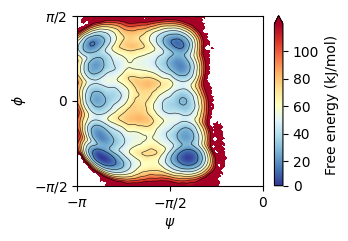

In [ ]:
import matplotlib 
matplotlib.rcParams['text.usetex'] = False


temperature=330
kT = 0.008314462618 * temperature
# From reweighting
fes_nonans, xedges, yedges = calculate_fes(cv1,cv2,bias,temperature, 1, nonans=False)
# Compute bin centers from edges
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])

# Create meshgrid of bin centers for plotting
X, Y = np.meshgrid(xcenters, ycenters, indexing='ij')
Z = fes_nonans

# From sum_hills
#fes=np.genfromtxt(os.path.join(cwd, f"fes_{fes_index}.dat"))
#plt.plot(fes[:,0],fes[:,1]-np.amin(fes[:,1]),label='sum_hills')

#X,Y,Z = calculate_kde(cv1,cv2,bias,temperature)
import mpltex
fsize = np.array([3, 2.20935])
#@mpltex.acs_decorator
def plot():
    fig, ax = plt.subplots(1,1, figsize=fsize)
    Z_masked = np.ma.masked_invalid(Z)
    #FES = compute_fes(Z)
    # Plotting
    spacing = kT*0.01
    levels = np.arange(Z_masked.min(), 120, spacing)
    levels2 = np.arange(Z_masked.min(), 120, kT*5)
    # Filled contour

    cf = ax.contourf(X, Y, Z_masked, levels=levels, cmap='RdYlBu_r', alpha=1, extend='max')
    # Contour lines
    cl = ax.contour(X, Y, Z_masked, levels=levels2, colors='black', linewidths=0.5, alpha=0.75) #cmap='RdYlBu_r'

    # Labels and colorbar
    ax.set_xlabel(r'$\psi$')
    ax.set_ylabel(r'$\phi$')
    ax.set_xlim([-np.pi, 0])
    ax.set_ylim([-np.pi/2, np.pi/2])

    xticks = [-np.pi, -np.pi/2, 0]
    xtick_labels = [r'$-\pi$', r'$-\pi/2$', '0']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels)

    yticks = [-np.pi/2, 0, np.pi/2]
    ytick_labels = [r'$-\pi/2$', '0', r'$\pi/2$']
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytick_labels)

    cbar = fig.colorbar(cf, ax=ax, label='Free energy (kJ/mol)')
    cbar.set_ticks([0, 20, 40, 60, 80, 100])
    cbar.set_ticklabels(['0', '20', '40', '60', '80', '100'])
    #ax.clabel(cl, fmt="%.1f", fontsize=8)
    #plt.savefig('FES-2d-vac-new.eps')
    #plt.savefig('FES-2d-vac-new.png')
    #plt.savefig('FES-2d-vac-new.pdf')
    print(Z.min())
    plt.show()
plot()
fes, xedges, yedges = calculate_fes(cv1,cv2,bias,temperature, 1)
# Compute bin centers from edges
xcenters = 0.5 * (xedges[:-1] + xedges[1:])
ycenters = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xcenters, ycenters, indexing='ij')
Z = fes